# IMDB Movie-Review Sentiment - Naive Bayes implemented from scratch

**HIT - Machine Learning course assignment**

| Student | ID (last 4 digits) |
|---|---|
| Tomer R. | 5130 |

- **Assignment type:** text analysis (NLP)
- **Learning type:** binary classification (positive vs negative review sentiment)
- **Algorithm implemented from scratch:** Naive Bayes - Multinomial, with a Bernoulli variant
- **Quality metric:** F1 macro-average
- **Dataset:** [IMDB 50K Movie Reviews](https://www.kaggle.com/datasets/atulanandjha/imdb-50k-movie-reviews-test-your-bert)
  (Stanford *Large Movie Review Dataset*), shipped pre-split into 25,000 train / 25,000 test, balanced 50/50.

This notebook runs a full supervised-learning flow: load the fixed train/test split, engineer text
features, implement Naive Bayes from scratch, tune it with 5-fold cross-validated grid search on the
training set only, retrain the best configuration on the whole training set, and evaluate once on the
untouched test set.

---
## Part 1 - Introduction

### 1a. AI assistance - prompts, tools and resources used

This assignment was developed with the help of **Claude (Anthropic)**, used through *Claude Code*.
All generated code and explanations were read, checked and understood before inclusion; the Naive
Bayes derivation below is standard textbook material (Manning, Raghavan & Schuetze, *Introduction to
Information Retrieval*, ch. 13) and was cross-checked against the scikit-learn user guide.

**What the AI was used for, with representative prompts (paraphrased):**

| Purpose | Prompt (paraphrased) |
|---|---|
| Understand the (machine-translated) brief | *"Read the assignment brief and explain exactly what each part requires."* |
| Choose a suitable dataset | *"Is the IMDB 50K movie-review dataset a good fit for a from-scratch Naive Bayes text-classification task that needs a pre-split train/test set with labels on both?"* |
| Derive and implement the algorithm | *"Derive Multinomial and Bernoulli Naive Bayes and implement them from scratch with a scikit-learn-style fit/predict, Laplace/Lidstone alpha smoothing and a fit_prior option, working in log space."* |
| Design the evaluation | *"Design a leakage-safe 5-fold cross-validated grid search over feature-engineering options x Naive Bayes hyper-parameters; the vectorizer must be fit inside each fold."* |
| Explanatory writing | *"Explain TF-IDF / n-grams / Laplace smoothing for a viewer who does not know the material."* |

**Full prompt record.** The table above is a summary. The complete record - every prompt in full,
what came back, and what was checked, changed or rejected each time - is kept in the repository at
[`docs/prompts/`](https://github.com/Tomer-Raz/machine-learning-hit/tree/main/docs/prompts), split
by project phase:

| | |
|---|---|
| [01](https://github.com/Tomer-Raz/machine-learning-hit/blob/main/docs/prompts/01-understanding-the-brief.md) | decoding the assignment brief |
| [02](https://github.com/Tomer-Raz/machine-learning-hit/blob/main/docs/prompts/02-dataset-selection.md) | choosing the dataset |
| [03](https://github.com/Tomer-Raz/machine-learning-hit/blob/main/docs/prompts/03-part1-loading-and-eda.md) | Part 1 - loading the given split, EDA |
| [04](https://github.com/Tomer-Raz/machine-learning-hit/blob/main/docs/prompts/04-quality-metric.md) | choosing and implementing the quality index |
| [05](https://github.com/Tomer-Raz/machine-learning-hit/blob/main/docs/prompts/05-part2-feature-engineering.md) | Part 2 - feature engineering |
| [06](https://github.com/Tomer-Raz/machine-learning-hit/blob/main/docs/prompts/06-part3-naive-bayes-from-scratch.md) | Part 3 - Naive Bayes from scratch |
| [07](https://github.com/Tomer-Raz/machine-learning-hit/blob/main/docs/prompts/07-part6a-grid-search-and-cv.md) | Part 6a - grid search + cross-validation |
| [08](https://github.com/Tomer-Raz/machine-learning-hit/blob/main/docs/prompts/08-parts4-5-final-model-and-test.md) | Parts 4 & 5 - final model and test evaluation |
| [09](https://github.com/Tomer-Raz/machine-learning-hit/blob/main/docs/prompts/09-verification-and-review.md) | auditing the finished work |
| [10](https://github.com/Tomer-Raz/machine-learning-hit/blob/main/docs/prompts/10-repo-docs-and-video.md) | repository, documentation and video |

Those prompts are reconstructed from the working sessions - they record the substance of what was
asked and the constraints imposed, condensed for reading rather than kept as a verbatim log.

**Other resources (not AI):**

- Manning, Raghavan & Schuetze, *Introduction to Information Retrieval*, ch. 13 - the Naive Bayes
  derivation, the Multinomial and Bernoulli models, and smoothing.
- scikit-learn User Guide - *Naive Bayes* and *Working with text data*.
- NLTK documentation - stopword list and the Porter stemmer.
- Stanford *Large Movie Review Dataset* page (Maas et al., 2011) - the dataset and its split.

### 1b. The learning problem and the dataset

We tackle **binary sentiment classification**: given the free text of an IMDB movie review, predict
whether the reviewer's opinion is **positive** or **negative**. The data is the Stanford *Large Movie
Review Dataset* (accessed via Kaggle): 50,000 "highly polar" English reviews - reviews rated 5 or 6
out of 10 were deliberately excluded, so every example is clearly positive (rating >= 7) or clearly
negative (rating <= 4). It arrives **already split** into 25,000 training and 25,000 test reviews,
each split perfectly balanced (12,500 positive + 12,500 negative), with a disjoint set of movies in
each. We keep this split fixed: the test set is set aside and used exactly once, at the very end.
All model selection happens by 5-fold cross-validation inside the training set.

### 1c. Setup

In [1]:
import re
import time
import random
import warnings
from pathlib import Path
from itertools import product

# Corporate networks often run a TLS-intercepting proxy that Python's bundled CA list
# does not trust. truststore makes Python use the OS trust store instead. On Colab / a
# normal network this is a harmless no-op.
try:
    import truststore
    truststore.inject_into_ssl()
except Exception:
    pass

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.naive_bayes import MultinomialNB as SklearnMultinomialNB  # reference parity check only

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*IProgress not found.*")  # tqdm in a plain kernel

print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.5.2 | pandas 3.0.5


### 1d. Load the train and test sets

The Kaggle dataset ships the **official Stanford split** as two files, `train.csv` and `test.csv`
(25,000 rows each), with columns `text` and `sentiment` (`pos` / `neg`). We load them as-is - **we
never build or re-shuffle the split** - rename to `review` / `label`, and map `neg -> 0`,
`pos -> 1`. The only cleaning here is dropping exact duplicate reviews *within* the training set
(96 of them); the test set is left completely untouched.

In [2]:
def load_imdb():
    # Return (df_train, df_test), each with columns ['review', 'label'] (label 0 = neg, 1 = pos).
    # Downloads from Kaggle via kagglehub (anonymous access works for this public dataset),
    # with a data/ folder fallback. The dataset's own train.csv / test.csv are the fixed split.
    root = None
    try:
        import kagglehub
        root = Path(kagglehub.dataset_download("atulanandjha/imdb-50k-movie-reviews-test-your-bert"))
    except Exception as e:
        print("kagglehub download failed (%r); looking in data/" % (e,))

    def _find(name):
        for base in [p for p in (root, Path("data")) if p is not None]:
            hits = sorted(base.rglob(name))
            if hits:
                return hits[0]
        return None

    def _read(path):
        try:
            df = pd.read_csv(path)
        except UnicodeDecodeError:
            df = pd.read_csv(path, encoding="latin-1")
        df.columns = [c.strip().lower() for c in df.columns]
        df = df.rename(columns={"sentimenttext": "review", "text": "review",
                                "sentiment": "label", "review_text": "review"})
        df = df[["review", "label"]].dropna()
        df["review"] = df["review"].astype(str)
        df["label"] = df["label"].map({"pos": 1, "neg": 0, "positive": 1, "negative": 0,
                                       1: 1, 0: 0, "1": 1, "0": 0})
        return df.dropna(subset=["label"]).astype({"label": int}).reset_index(drop=True)

    tr_path, te_path = _find("train.csv"), _find("test.csv")
    if tr_path is None or te_path is None:
        raise FileNotFoundError("train.csv / test.csv not found via kagglehub or data/")
    print("train file:", tr_path)
    print("test  file:", te_path)

    tr = _read(tr_path).drop_duplicates(subset="review").reset_index(drop=True)
    te = _read(te_path)
    return tr, te


df_train, df_test = load_imdb()
print("train:", df_train.shape, "  test:", df_test.shape)

train file: /Users/traz/.cache/kagglehub/datasets/atulanandjha/imdb-50k-movie-reviews-test-your-bert/versions/2/train.csv
test  file: /Users/traz/.cache/kagglehub/datasets/atulanandjha/imdb-50k-movie-reviews-test-your-bert/versions/2/test.csv


train: (24904, 2)   test: (25000, 2)


**First 5 rows of the training set:**

In [3]:
df_train.head()

,review,label
0,"Now, I won't deny that when I purchased this off eBay, I had high expectations. This was an incredible out-of-print work from the master of comedy that I so enjoy. However, I was soon to be disapp...",0
1,"The saddest thing about this ""tribute"" is that almost all the singers (including the otherwise incredibly talented Nick Cave) seem to have missed the whole point where Cohen's intensity lies: by d...",0
2,"Last night I decided to watch the prequel or shall I say the so called prequel to Carlito's Way - ""Carlito's Way: Rise to Power (2005)"" which went straight to DVD...no wonder .....it completely .....",0
3,"I have to admit that i liked the first half of Sleepers. It looked good, the acting was even better, the story of childhood, pain and revenge was interesting and moving. A superior hollywood film....",0
4,"I was not impressed about this film especially for the fact that I went to the cinema with my family in good faith to see a film which was certificate rated 12A here in the UK. To my dismay, this ...",0


**First 5 rows of the test set:**

In [4]:
df_test.head()

,review,label
0,"My daughter liked it but I was aghast, that a character in this movie smokes. As if it isn't awful enough to see ""product placement"" actors like Bruce Willis who smoke in their movies - at least c...",0
1,I... No words. No words can describe this. I will try for the sake of those few brave people who stick knives into their toasters... after watching this show.<br /><br />This... Cosgrove person......,0
2,"this film is basically a poor take on the old urban legend of the babysitter who gets crank calls telling her to check the children, she calls the police who trace the calls and find there coming ...",0
3,"This is a terrible movie, and I'm not even sure why it's so terrible. It's ugly, for one, with that trendy 1970s visual style that maybe seemed like a good idea at the time but which now enables o...",0
4,"First of all this movie is a piece of reality very well realized artistically. Some kind of combination between ""American Beauty"" and ""As Good as it gets"". And of course something specifically to ...",1


### 1e. A quick look at the data

Both splits should be balanced 50/50. We also check for obvious data-quality issues and glance at
review length, which motivates a few feature-engineering choices in Part 2 (HTML `<br />` tags to
strip, very long reviews, and so on).

train n= 24904  neg(0)= 12432  pos(1)= 12472  nulls=0  empty=0
test  n= 25000  neg(0)= 12500  pos(1)= 12500  nulls=0  empty=0

exact review text shared between train and test: 123 (0.49% of test) - left as-is; too small to matter and we must not alter the given split


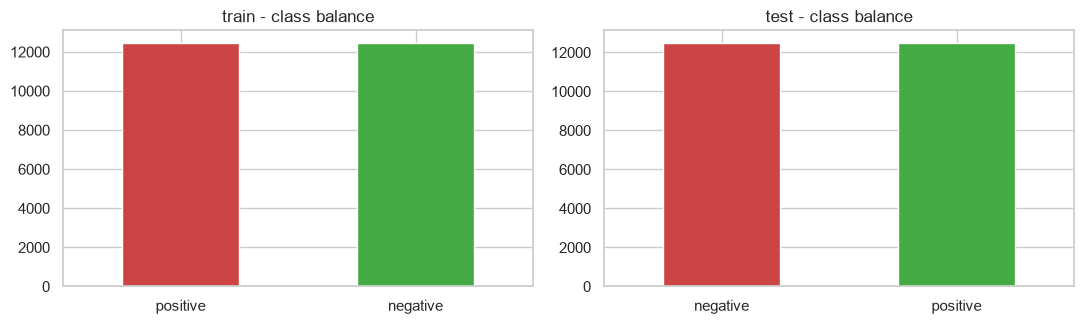


review length (words): min 10, median 174, mean 234, 95th pct 599, max 2470

example raw review (first 400 chars):
 Now, I won't deny that when I purchased this off eBay, I had high expectations. This was an incredible out-of-print work from the master of comedy that I so enjoy. However, I was soon to be disappointed. Apologies to those who enjoyed it, but I just found the Compleat Al to be very difficult to watch. I got a few smiles, sure, but the majority of the funny came from the music videos (which I've go


In [5]:
for name, d in [("train", df_train), ("test", df_test)]:
    c = d["label"].value_counts().sort_index()
    print("%-5s n=%6d  neg(0)=%6d  pos(1)=%6d  nulls=%d  empty=%d" % (
        name, len(d), c.get(0, 0), c.get(1, 0),
        d["review"].isna().sum(), (d["review"].str.strip() == "").sum()))

overlap = len(set(df_train["review"]) & set(df_test["review"]))
print("\nexact review text shared between train and test: %d (%.2f%% of test) - left as-is; "
      "too small to matter and we must not alter the given split" % (overlap, 100 * overlap / len(df_test)))

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for a, (name, d) in zip(ax, [("train", df_train), ("test", df_test)]):
    (d["label"].map({0: "negative", 1: "positive"}).value_counts()
        .plot.bar(ax=a, color=["#cc4444", "#44aa44"]))
    a.set_title(name + " - class balance"); a.set_xlabel(""); a.tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()

wl = df_train["review"].str.split().str.len()
print("\nreview length (words): min %d, median %d, mean %.0f, 95th pct %d, max %d" % (
    wl.min(), wl.median(), wl.mean(), wl.quantile(0.95), wl.max()))
print("\nexample raw review (first 400 chars):\n", df_train["review"].iloc[0][:400])

---
## Quality index - which metric, and why

The brief fixes the metric by problem type:

| Problem type | Metric |
|---|---|
| Regression | R-squared |
| Multi-class, **or** binary with no single "class of interest" | **F1, macro-averaged** |
| Binary with one "central" class of interest (e.g. *spam* in spam detection) | F1 of that class only |

Our problem is **binary** (positive / negative) and the classes are **balanced and equally
important** - there is no single "central" class we care about more, unlike spam detection. So the
middle row applies: **macro-averaged F1** - F1 for the positive class and F1 for the negative class,
averaged. On perfectly balanced data this sits very close to plain accuracy and to positive-class
F1, but it is the metric the brief asks for and it stays honest if a preprocessing choice ever
unbalances a validation fold.

`score()` below is the single scoring function used **everywhere**: every fold in cross-validation,
the grid-search ranking, and the final test-set report.

In [6]:
def score(y_true, y_pred):
    # Macro-averaged F1 - the assignment's quality index for this problem.
    return f1_score(y_true, y_pred, average="macro")


print("score() smoke test:", round(score([0, 0, 1, 1, 1], [0, 1, 1, 1, 0]), 4))

score() smoke test: 0.5833


---
## Part 2 - Feature engineering

A learning algorithm needs numbers, not prose. Feature engineering is the process of turning each
raw review into a fixed-length numeric vector. For text the standard pipeline is:

**1. Text cleaning / normalisation.** Lower-case everything (so *Great* and *great* are the same
token), strip the HTML that litters these reviews (`<br />`), drop URLs, and remove digits and
punctuation. This shrinks the vocabulary to the parts that carry meaning.

**2. Tokenisation.** Split the cleaned string into *tokens* (here: runs of >= 2 letters). A review
becomes a list of words.

**3. Optional token filtering.**
- *Stop-word removal* - drop extremely common words (`the`, `is`, `and`, ...). It trims noise, but
  note that English stop-word lists also contain `not`, `no`, `very`, `never` - words that clearly
  matter for **sentiment** - so for this task removing them can *hurt*. We therefore make it a knob
  and test both settings in Part 6a.
- *Stemming* - chop words to a common root (`amazing`, `amazed`, `amazingly` -> `amaz`) with the
  Porter stemmer. Fewer, denser features; occasionally over-merges.

**4. Vectorisation - from tokens to a document-term matrix.**
- *Bag-of-Words (BoW)* - one column per vocabulary term; the entry is the **count** of that term in
  the document. Order is thrown away.
- *TF-IDF* - the same matrix, but each count is reweighted by *term frequency x inverse document
  frequency*: terms that appear in almost every review (weak signal) are down-weighted, rare
  informative terms are boosted.
- *n-grams* - also index short word sequences. Unigrams `(1,1)` treat `not good` as `not` + `good`;
  adding bigrams `(1,2)` gives the model the single feature `not good`, which is very useful for
  sentiment.
- *Vocabulary pruning* - `min_df` drops terms seen in fewer than *k* documents (kills typos),
  `max_df` drops terms seen in more than a fraction of documents (kills corpus-specific stop
  words), `max_features` caps the vocabulary at the most frequent *N* terms.

The matrix is huge but almost all zeros, so it is stored **sparse**.

### 2a. Cleaning, tokenisation and the vectorizer factory

`clean_text` and `tokenize` are the actual functions the vectorizer uses (as its `preprocessor`
and `tokenizer`), so the step-by-step demo below and the full pipeline share exactly one code
path. `build_vectorizer(...)` is the single knob-box that Part 6a's grid search will sweep.

In [7]:
from functools import lru_cache
from nltk.stem import PorterStemmer

_HTML_RE = re.compile(r"<[^>]+>")
_URL_RE = re.compile(r"https?://\S+|www\.\S+")
_KEEP_RE = re.compile(r"[^a-z\s]+")       # after lower-casing, keep only letters and spaces
_TOKEN_RE = re.compile(r"[a-z]{2,}")       # tokens = runs of >= 2 letters
_stem = lru_cache(maxsize=300_000)(PorterStemmer().stem)


def clean_text(s):
    # raw review -> normalised string (lower-case, no HTML / URLs / digits / punctuation)
    s = s.lower()
    s = _HTML_RE.sub(" ", s)
    s = _URL_RE.sub(" ", s)
    s = _KEEP_RE.sub(" ", s)
    return s


def tokenize(s, use_stemming=False, remove_stopwords=False):
    # normalised string -> list of tokens, with optional stop-word removal then stemming
    toks = _TOKEN_RE.findall(s)
    if remove_stopwords:
        toks = [t for t in toks if t not in ENGLISH_STOP_WORDS]
    if use_stemming:
        toks = [_stem(t) for t in toks]
    return toks


def build_vectorizer(kind="tfidf", ngram_range=(1, 1), use_stemming=False,
                     remove_stopwords=False, min_df=5, max_df=0.9,
                     max_features=50_000, binary=False):
    # Return a configured (unfitted) CountVectorizer / TfidfVectorizer.
    # kind: "bow" (counts) or "tfidf". binary=True + "bow" pairs with Bernoulli NB.
    shared = dict(
        preprocessor=clean_text,
        tokenizer=lambda s: tokenize(s, use_stemming, remove_stopwords),
        token_pattern=None,
        ngram_range=ngram_range,
        min_df=min_df,
        max_df=max_df,
        max_features=max_features,
    )
    if kind == "bow":
        return CountVectorizer(binary=binary, **shared)
    if kind == "tfidf":
        return TfidfVectorizer(**shared)
    raise ValueError("kind must be 'bow' or 'tfidf'")


print("stemmer check:", [_stem(w) for w in ["amazing", "amazed", "amazingly", "movies", "acting"]])
print("clean_text on a snippet:", repr(clean_text("It's <br />GREAT!! visit http://x.com 10/10")))

stemmer check: ['amaz', 'amaz', 'amazingli', 'movi', 'act']
clean_text on a snippet: 'it s  great  visit    '


### 2b. The pipeline step-by-step on real examples

Three reviews - a positive and a negative one from **train**, and one from **test** - taken through
every text stage:

In [8]:
demo = pd.concat([
    df_train[df_train.label == 1].iloc[[0]].assign(split="train"),
    df_train[df_train.label == 0].iloc[[0]].assign(split="train"),
    df_test.iloc[[1]].assign(split="test"),
], ignore_index=True)

stages = []
for _, r in demo.iterrows():
    cleaned = clean_text(r["review"])
    toks = tokenize(cleaned)
    no_stop = tokenize(cleaned, remove_stopwords=True)
    stemmed = tokenize(cleaned, use_stemming=True, remove_stopwords=True)
    stages.append({
        "split": r["split"],
        "label": int(r["label"]),
        "1_raw (first 140 chars)": r["review"][:140] + " ...",
        "2_cleaned (first 140)": cleaned[:140] + " ...",
        "3_tokens (n)": len(toks),
        "4_tokens (first 16)": " ".join(toks[:16]),
        "5_minus_stopwords (first 16)": " ".join(no_stop[:16]),
        "6_stemmed (first 16)": " ".join(stemmed[:16]),
    })
pd.set_option("display.max_colwidth", 160)
pd.DataFrame(stages).T

,0,1,2
split,train,train,test
label,1,0,0
1_raw (first 140 chars),"The original movie, The Odd Couple, has some wonderful comic one-liners. The entire world it seems knows the story of neurotic neat-freak Fe ...","Now, I won't deny that when I purchased this off eBay, I had high expectations. This was an incredible out-of-print work from the master of ...",I... No words. No words can describe this. I will try for the sake of those few brave people who stick knives into their toasters... after w ...
2_cleaned (first 140),the original movie the odd couple has some wonderful comic one liners the entire world it seems knows the story of neurotic neat freak fe ...,now i won t deny that when i purchased this off ebay i had high expectations this was an incredible out of print work from the master of ...,i no words no words can describe this i will try for the sake of those few brave people who stick knives into their toasters after watch ...
3_tokens (n),502,132,303
4_tokens (first 16),the original movie the odd couple has some wonderful comic one liners the entire world it,now won deny that when purchased this off ebay had high expectations this was an incredible,no words no words can describe this will try for the sake of those few brave
5_minus_stopwords (first 16),original movie odd couple wonderful comic liners entire world knows story neurotic neat freak felix ungar,won deny purchased ebay high expectations incredible print work master comedy enjoy soon disappointed apologies enjoyed,words words try sake brave people stick knives toasters watching cosgrove person acting like watching female
6_stemmed (first 16),origin movi odd coupl wonder comic liner entir world know stori neurot neat freak felix ungar,won deni purchas ebay high expect incred print work master comedi enjoy soon disappoint apolog enjoy,word word tri sake brave peopl stick knive toaster watch cosgrov person act like watch femal


In [9]:
# From tokens to numbers. (a) raw Bag-of-Words counts on just these 3 reviews -- the mechanism,
# but the largest counts are inevitably function words:
bow_demo = build_vectorizer(kind="bow", ngram_range=(1, 1), min_df=1, max_df=1.0, max_features=None)
Bd = bow_demo.fit_transform(demo["review"])
vd = np.array(bow_demo.get_feature_names_out())
for i in range(len(demo)):
    row = Bd[i].toarray().ravel(); nz = row.nonzero()[0]
    order = nz[np.argsort(-row[nz])][:10]
    print("doc %d (%s,label=%d): %d unique tokens; highest counts: %s"
          % (i, demo["split"][i], demo["label"][i], len(nz),
             ", ".join("%s=%d" % (vd[j], row[j]) for j in order)))

doc 0 (train,label=1): 252 unique tokens; highest counts: the=51, of=17, felix=12, that=10, is=10, and=8, in=8, movie=8, very=7, it=7
doc 1 (train,label=0): 91 unique tokens; highest counts: the=8, to=7, that=4, this=4, was=4, al=3, of=3, just=3, off=2, it=2
doc 2 (test,label=0): 188 unique tokens; highest counts: the=23, of=19, this=10, you=6, that=6, show=5, have=5, for=4, her=4, if=4


In [10]:
# (b) the same 3 reviews as TF-IDF over unigrams+bigrams, with the IDF weights and vocabulary
# learned from the FULL training set (min_df=5) -- now the sentiment-bearing terms rise to the top.
base_vec = build_vectorizer(kind="tfidf", ngram_range=(1, 2), min_df=5, max_features=50_000)
base_vec.fit(df_train["review"])
Td = base_vec.transform(demo["review"])
vt = base_vec.get_feature_names_out()
for i in range(len(demo)):
    row = Td[i].toarray().ravel(); nz = row.nonzero()[0]
    order = nz[np.argsort(-row[nz])][:12]
    print("doc %d (%s,label=%d): %d non-zero features; highest TF-IDF: %s"
          % (i, demo["split"][i], demo["label"][i], len(nz),
             ", ".join("%s=%.2f" % (vt[j], row[j]) for j in order)))

doc 0 (train,label=1): 475 non-zero features; highest TF-IDF: felix=0.48, ungar=0.20, oscar=0.18, tv series=0.16, series=0.14, jack=0.13, odd couple=0.13, the tv=0.12, lemmon=0.12, the odd=0.11, tv=0.10, madison=0.09
doc 1 (train,label=0): 164 non-zero features; highest TF-IDF: al=0.24, ebay=0.22, which ve=0.12, of print=0.12, deny that=0.12, ever make=0.11, doubt if=0.11, music videos=0.11, got on=0.11, who enjoyed=0.11, an ultra=0.11, dvd so=0.11
doc 2 (test,label=0): 312 non-zero features; highest TF-IDF: this show=0.18, no words=0.15, show=0.14, day of=0.12, this will=0.12, if you=0.10, you=0.09, will=0.09, her=0.09, eventually=0.09, brother=0.08, words=0.08


### 2c. Baseline feature matrix

Using that same fitted vectorizer - **TF-IDF, unigrams+bigrams, `min_df=5`, `max_features=50000`** -
we transform the training set. Part 6a searches for a better configuration; this establishes the
shapes and gives Part 3 real data to run on.

The test set is deliberately **not** transformed here. It is loaded and described in Part 1, and one
test review is traced through the pipeline in 2b as the brief requires, but no test feature matrix
exists until Part 5 - so no code before Part 5 can accidentally learn anything from it.

In [11]:
t0 = time.time()
Xtr = base_vec.transform(df_train["review"])
ytr = df_train["label"].to_numpy()

density = Xtr.nnz / (Xtr.shape[0] * Xtr.shape[1])
print("baseline TF-IDF, (1,2)-grams, min_df=5, max_features=50000")
print("  X_train: %s     vocab: %d" % (Xtr.shape, len(base_vec.vocabulary_)))
print("  matrix density: %.4f%%   transformed in %.1fs" % (100 * density, time.time() - t0))
print("  (no test matrix is built here - the test set is first transformed in Part 5)")

baseline TF-IDF, (1,2)-grams, min_df=5, max_features=50000
  X_train: (24904, 50000)     vocab: 50000
  matrix density: 0.4725%   transformed in 3.2s
  (no test matrix is built here - the test set is first transformed in Part 5)


---
## Part 3 - Naive Bayes, implemented from scratch

### 3a. The idea

Naive Bayes is a probabilistic classifier built on **Bayes' rule**. To label a document *d* we pick
the class *c* that maximises the posterior probability *P(c | d)*. Bayes' rule rewrites that as

$$P(c \mid d) \;\propto\; P(c)\, P(d \mid c)$$

- **$P(c)$ - the prior:** how frequent class *c* is overall.
- **$P(d \mid c)$ - the likelihood:** how typical document *d* looks for class *c*.

The **"naive"** part is the assumption that the features (words) are **conditionally independent
given the class**. That is clearly false for real language, but it makes the parameters trivial to
estimate from counts and, empirically, the classifier is strong for text.

**Multinomial model.** A document is a bag of word counts; word *i* occurs $x_i$ times over a
vocabulary of size $V$:

$$P(d \mid c) \;\propto\; \prod_{i=1}^{V} P(w_i \mid c)^{\,x_i}$$

Each $P(w_i \mid c)$ is estimated by counting, with **Laplace / Lidstone smoothing** of strength
$\alpha$ so that an unseen word does not zero out the whole product:

$$P(w_i \mid c) \;=\; \frac{N_{ci} + \alpha}{N_c + \alpha V},
\qquad N_{ci} = \text{count of word }i\text{ in class }c,\quad N_c = \sum_i N_{ci}.$$

**Work in log space.** Multiplying thousands of small probabilities underflows to 0, so we take
logs and *add*:

$$\log P(c \mid d) \;=\; \log P(c) \;+\; \sum_i x_i \, \log P(w_i \mid c) \;+\; \text{const},$$

and predict $\arg\max_c$. Vectorised over a document-term matrix $X$ this is one matrix product:
`jll = X @ feature_log_prob_.T + class_log_prior_`.

**Bernoulli model (a variant we also try).** Here a document is a set of binary present/absent
flags $b_i$; counts are ignored and, importantly, **absent** words contribute too:

$$\log P(c \mid d) = \log P(c) + \sum_i \big[\, b_i \log p_{ci} + (1 - b_i)\log(1 - p_{ci}) \,\big],
\qquad p_{ci} = \frac{\mathrm{df}_{ci} + \alpha}{N_c + 2\alpha},$$

where $\mathrm{df}_{ci}$ is the number of class-*c* documents that contain word *i*.

**Hyper-parameters exposed** (as taught in class): `alpha` (smoothing strength), `fit_prior`
(estimate $P(c)$ from data vs. assume uniform), and `model_type` (`"multinomial"` or
`"bernoulli"`).

### 3b. Implementation

A scikit-learn-style estimator: `fit(X, y)` then `predict(X)` / `predict_proba(X)`, where `X` is a
document-term matrix (dense or SciPy sparse, as produced by the vectorizers in Part 2). Everything
is done with vectorised NumPy in log space.

In [12]:
def _logsumexp(a, axis=None, keepdims=False):
    a_max = np.max(a, axis=axis, keepdims=True)
    out = np.log(np.sum(np.exp(a - a_max), axis=axis, keepdims=True)) + a_max
    return out if keepdims else np.squeeze(out, axis=axis)


class NaiveBayesTextClassifier:
    # Multinomial / Bernoulli Naive Bayes for text, implemented from scratch.
    #   alpha      : additive (Laplace/Lidstone) smoothing strength
    #   fit_prior  : learn P(c) from data if True, else uniform prior
    #   model_type : "multinomial" (term counts) or "bernoulli" (binary presence + absence)

    def __init__(self, alpha=1.0, fit_prior=True, model_type="multinomial"):
        self.alpha = float(alpha)
        self.fit_prior = bool(fit_prior)
        self.model_type = model_type

    def _indicator(self, y):
        # (n_classes, n_samples) 0/1 matrix; row k selects the samples of classes_[k]
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        return np.stack([(y == c).astype(np.float64) for c in self.classes_])

    def fit(self, X, y):
        if self.model_type not in ("multinomial", "bernoulli"):
            raise ValueError("model_type must be 'multinomial' or 'bernoulli'")
        Xc = X.tocsr().astype(np.float64) if sp.issparse(X) else np.asarray(X, dtype=np.float64)
        if self.model_type == "bernoulli":
            Xc = (Xc > 0).astype(np.float64)

        Y = self._indicator(y)                       # (K, n)
        self.class_count_ = Y.sum(axis=1)            # (K,)  docs per class
        self.feature_count_ = np.asarray(Y @ Xc)     # (K, V)  counts (mult) / doc-freqs (bern)
        n_classes, self.n_features_in_ = self.feature_count_.shape

        if self.fit_prior:
            self.class_log_prior_ = np.log(self.class_count_ / self.class_count_.sum())
        else:
            self.class_log_prior_ = np.full(n_classes, -np.log(n_classes))

        if self.model_type == "multinomial":
            smoothed_fc = self.feature_count_ + self.alpha
            smoothed_cc = smoothed_fc.sum(axis=1, keepdims=True)          # (K, 1)
            self.feature_log_prob_ = np.log(smoothed_fc) - np.log(smoothed_cc)
        else:
            prob = (self.feature_count_ + self.alpha) / (self.class_count_[:, None] + 2 * self.alpha)
            self.feature_log_prob_ = np.log(prob)         # log P(term present | c)
            self._neg_log_prob = np.log(1.0 - prob)       # log P(term absent  | c)
        return self

    def _joint_log_likelihood(self, X):
        # unnormalised log P(c, d) for every doc/class -> shape (n_docs, n_classes)
        Xc = X.tocsr().astype(np.float64) if sp.issparse(X) else np.asarray(X, dtype=np.float64)
        if self.model_type == "bernoulli":
            Xc = (Xc > 0).astype(np.float64)
            delta = self.feature_log_prob_ - self._neg_log_prob
            jll = Xc @ delta.T + self.class_log_prior_ + self._neg_log_prob.sum(axis=1)
        else:
            jll = Xc @ self.feature_log_prob_.T + self.class_log_prior_
        return np.asarray(jll)

    def predict(self, X):
        return self.classes_[np.argmax(self._joint_log_likelihood(X), axis=1)]

    def predict_log_proba(self, X):
        jll = self._joint_log_likelihood(X)
        return jll - _logsumexp(jll, axis=1, keepdims=True)

    def predict_proba(self, X):
        return np.exp(self.predict_log_proba(X))

### 3c. Correctness check

Same maths as scikit-learn's `MultinomialNB` / `BernoulliNB`, so our estimates and predictions
should match theirs to floating-point tolerance. We check on synthetic count data and on a small
text corpus, across several `alpha` and `fit_prior` settings. (scikit-learn is used **only** as a
reference here - never as the model.)

In [13]:
from sklearn.naive_bayes import BernoulliNB as _SkBernoulliNB

_rng = np.random.default_rng(0)
_Xchk = sp.csr_matrix(_rng.integers(0, 5, size=(300, 25)).astype(float))
_ychk = _rng.integers(0, 3, size=300)

_max_diff = 0.0
for _a in (0.01, 0.5, 1.0, 2.0):
    for _fp in (True, False):
        _m = NaiveBayesTextClassifier(alpha=_a, fit_prior=_fp, model_type="multinomial").fit(_Xchk, _ychk)
        _s = SklearnMultinomialNB(alpha=_a, fit_prior=_fp).fit(_Xchk, _ychk)
        _max_diff = max(_max_diff, np.abs(_m.predict_log_proba(_Xchk) - _s.predict_log_proba(_Xchk)).max())
        assert (_m.predict(_Xchk) == _s.predict(_Xchk)).all()

        _mb = NaiveBayesTextClassifier(alpha=_a, fit_prior=_fp, model_type="bernoulli").fit(_Xchk, _ychk)
        _sb = _SkBernoulliNB(alpha=_a, fit_prior=_fp, binarize=0.0).fit(_Xchk, _ychk)
        _max_diff = max(_max_diff, np.abs(_mb.predict_log_proba(_Xchk) - _sb.predict_log_proba(_Xchk)).max())
        assert (_mb.predict(_Xchk) == _sb.predict(_Xchk)).all()

print("synthetic data: multinomial + bernoulli match scikit-learn; max |log-prob diff| = %.2e" % _max_diff)

# ...and on the real baseline IMDB features from Part 2. The comparison needs data the two models
# were not fitted on, and it must NOT be the test set - that is reserved for Part 5 - so we hold out
# a stratified fifth of the TRAINING set for it.
_fit_i, _chk_i = next(StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
                      .split(np.zeros(len(ytr)), ytr))
_ours = NaiveBayesTextClassifier(alpha=0.1).fit(Xtr[_fit_i], ytr[_fit_i])
_ref = SklearnMultinomialNB(alpha=0.1).fit(Xtr[_fit_i], ytr[_fit_i])
_pred_ours, _pred_ref = _ours.predict(Xtr[_chk_i]), _ref.predict(Xtr[_chk_i])
_real_diff = np.abs(_ours.predict_log_proba(Xtr[_chk_i]) - _ref.predict_log_proba(Xtr[_chk_i])).max()
assert (_pred_ours == _pred_ref).all()

print("real IMDB features: fitted both on %d training reviews, compared on the %d held-out"
      % (len(_fit_i), len(_chk_i)))
print("                    training reviews - predictions identical, max |log-prob diff| = %.2e"
      % _real_diff)
print("                    our from-scratch NB macro-F1 on that held-out slice = %.4f"
      % score(ytr[_chk_i], _pred_ours))
print("                    (the test set is untouched until Part 5)")

synthetic data: multinomial + bernoulli match scikit-learn; max |log-prob diff| = 1.42e-13
real IMDB features: fitted both on 19923 training reviews, compared on the 4981 held-out
                    training reviews - predictions identical, max |log-prob diff| = 4.26e-13
                    our from-scratch NB macro-F1 on that held-out slice = 0.8892
                    (the test set is untouched until Part 5)


---
## Part 6a - Experimenting with feature engineering and hyper-parameters

We now search for the best pipeline by **5-fold cross-validation on the training set only**. The
test set is not touched here at all.

**k-fold cross-validation.** Split the training set into 5 equal, class-stratified parts. Five
times, train on 4 parts and measure the quality index on the held-out part. The 5 held-out scores
are averaged - this estimates how well a configuration generalises, using every training review
for validation exactly once and without ever looking at the test set.

**Grid search.** Try every combination in the Cartesian product of:

| Axis | Values | Kind |
|---|---|---|
| vectorizer | Bag-of-Words, TF-IDF | feature engineering |
| n-gram range | (1,1) unigrams, (1,2) uni+bigrams | feature engineering |
| stemming | off, on (Porter) | feature engineering |
| `model_type` | Multinomial, Bernoulli (Bernoulli only pairs with BoW) | hyper-parameter |
| `alpha` | 0.1, 0.5, 1.0 | hyper-parameter |

(Stop-word removal is examined separately in 6a-ii, and `min_df` in 6a-iii, so the main grid stays
a readable size.)

**No leakage.** For every fold the vectorizer is re-fit **from scratch on that fold's 4 training
parts** and merely *applies* to the held-out part - the vocabulary and the IDF weights never see
the validation reviews.

In [14]:
def cv_folds(y, n_splits=5, seed=RANDOM_STATE):
    return list(StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed).split(y, y))


def run_grid(texts, y, grid, n_splits=5, seed=RANDOM_STATE, verbose=True):
    # grid: list of (feature_kwargs, nb_kwargs). Vectorise once per unique feature config per
    # fold, then score every NB config that uses it. Returns a DataFrame, one row per permutation.
    folds = cv_folds(y, n_splits, seed)
    fe_configs = []
    for fe, _ in grid:
        if fe not in fe_configs:
            fe_configs.append(fe)

    rows = []
    for fe in fe_configs:
        t0 = time.time()
        mats = []
        for tr, va in folds:
            vec = build_vectorizer(**fe)
            mats.append((vec.fit_transform(texts[tr]), y[tr], vec.transform(texts[va]), y[va]))
        vt = time.time() - t0
        for nb in [n for f, n in grid if f == fe]:
            s = np.array([score(yv, NaiveBayesTextClassifier(**nb).fit(Xt, yt).predict(Xv))
                          for Xt, yt, Xv, yv in mats])
            rows.append({
                "vectorizer": fe["kind"], "ngrams": str(fe["ngram_range"]),
                "stemming": fe["use_stemming"], "stopwords_removed": fe.get("remove_stopwords", False),
                "min_df": fe["min_df"], "model_type": nb["model_type"], "alpha": nb["alpha"],
                "cv_mean_f1": s.mean(), "cv_std_f1": s.std(), "fold_f1": np.round(s, 4).tolist(),
            })
        del mats
        if verbose:
            print("  %-5s %-6s stem=%-5s min_df=%-2s : 5 folds vectorised in %4.1fs"
                  % (fe["kind"], fe["ngram_range"], fe["use_stemming"], fe["min_df"], vt))
    return (pd.DataFrame(rows)
            .sort_values("cv_mean_f1", ascending=False, ignore_index=True))


MAIN_GRID = []
for _kind in ("bow", "tfidf"):
    for _ng in [(1, 1), (1, 2)]:
        for _use_stem in (False, True):
            _fe = dict(kind=_kind, ngram_range=_ng, use_stemming=_use_stem,
                       remove_stopwords=False, min_df=5, max_features=30_000)
            _mtypes = ("multinomial", "bernoulli") if _kind == "bow" else ("multinomial",)
            for _mt in _mtypes:
                for _alpha in (0.1, 0.5, 1.0):
                    MAIN_GRID.append((_fe, dict(model_type=_mt, alpha=_alpha)))

print("main grid: %d permutations over %d unique feature configs"
      % (len(MAIN_GRID), len({tuple(sorted(f.items())) for f, _ in MAIN_GRID})))

main grid: 36 permutations over 8 unique feature configs


In [15]:
_t0 = time.time()
results_df = run_grid(df_train["review"].to_numpy(), df_train["label"].to_numpy(), MAIN_GRID)
print("\ngrid search finished in %.0f s" % (time.time() - _t0))
results_df

  bow   (1, 1) stem=False min_df=5  : 5 folds vectorised in  8.0s


  bow   (1, 1) stem=True  min_df=5  : 5 folds vectorised in  9.6s


  bow   (1, 2) stem=False min_df=5  : 5 folds vectorised in 26.3s


  bow   (1, 2) stem=True  min_df=5  : 5 folds vectorised in 26.8s


  tfidf (1, 1) stem=False min_df=5  : 5 folds vectorised in  8.0s


  tfidf (1, 1) stem=True  min_df=5  : 5 folds vectorised in  9.3s


  tfidf (1, 2) stem=False min_df=5  : 5 folds vectorised in 29.3s


  tfidf (1, 2) stem=True  min_df=5  : 5 folds vectorised in 26.8s

grid search finished in 155 s


,vectorizer,ngrams,stemming,stopwords_removed,min_df,model_type,alpha,cv_mean_f1,cv_std_f1,fold_f1
0,tfidf,"(1, 2)",True,False,5,multinomial,0.1,0.877882,0.004009,"[0.8815, 0.8767, 0.8827, 0.8769, 0.8715]"
1,tfidf,"(1, 2)",False,False,5,multinomial,0.1,0.877200,0.003764,"[0.8819, 0.8739, 0.8815, 0.8733, 0.8753]"
2,tfidf,"(1, 2)",False,False,5,multinomial,1.0,0.877127,0.002534,"[0.8797, 0.8761, 0.8801, 0.8733, 0.8763]"
3,tfidf,"(1, 2)",True,False,5,multinomial,0.5,0.877043,0.003728,"[0.8817, 0.8755, 0.8811, 0.8743, 0.8725]"
4,tfidf,"(1, 2)",False,False,5,multinomial,0.5,0.877004,0.003013,"[0.8797, 0.8747, 0.8813, 0.8735, 0.8757]"
5,tfidf,"(1, 2)",True,False,5,multinomial,1.0,0.876444,0.003996,"[0.8809, 0.8739, 0.8815, 0.8739, 0.8719]"
6,bow,"(1, 2)",True,False,5,bernoulli,0.1,0.871821,0.003602,"[0.8743, 0.8687, 0.8777, 0.8691, 0.8693]"
7,bow,"(1, 2)",True,False,5,bernoulli,0.5,0.871219,0.003497,"[0.8745, 0.8681, 0.8763, 0.8681, 0.8691]"
8,bow,"(1, 2)",True,False,5,bernoulli,1.0,0.870939,0.003686,"[0.8749, 0.8677, 0.8759, 0.8677, 0.8685]"
9,bow,"(1, 2)",False,False,5,bernoulli,0.1,0.869889,0.001253,"[0.8717, 0.8705, 0.8695, 0.8679, 0.8699]"


### Best configuration from the main grid

best permutation (cross-validated macro-F1 = 0.8779  +/- 0.0040):

vectorizer                                       tfidf
ngrams                                          (1, 2)
stemming                                          True
model_type                                 multinomial
alpha                                              0.1
fold_f1       [0.8815, 0.8767, 0.8827, 0.8769, 0.8715]


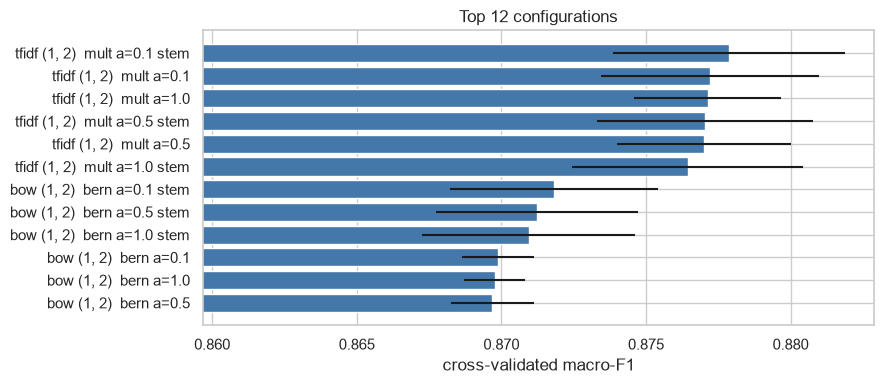

In [16]:
best_row = results_df.iloc[0]
print("best permutation (cross-validated macro-F1 = %.4f  +/- %.4f):\n" % (
    best_row["cv_mean_f1"], best_row["cv_std_f1"]))
print(best_row[["vectorizer", "ngrams", "stemming", "model_type", "alpha", "fold_f1"]].to_string())

fig, ax = plt.subplots(figsize=(9, 4))
_top = results_df.head(12).iloc[::-1]
_lab = _top["vectorizer"] + " " + _top["ngrams"] + "  " + _top["model_type"].str[:4] \
       + " a=" + _top["alpha"].astype(str) + (_top["stemming"].map({True: " stem", False: ""}))
ax.barh(_lab, _top["cv_mean_f1"], xerr=_top["cv_std_f1"], color="#4477aa")
ax.set_xlim(_top["cv_mean_f1"].min() - 0.01, results_df["cv_mean_f1"].max() + 0.005)
ax.set_xlabel("cross-validated macro-F1"); ax.set_title("Top 12 configurations"); plt.tight_layout(); plt.show()

### 6a-ii. Feature-engineering experiment - stop-word removal

Taking the winning vectorizer/model, does removing English stop words help? For sentiment it often
does **not**, because words like *not*, *no*, *very* are on the stop-word list.

In [17]:
_NG = {"(1, 1)": (1, 1), "(1, 2)": (1, 2)}
_fe_base = dict(kind=best_row["vectorizer"], ngram_range=_NG[best_row["ngrams"]],
                use_stemming=bool(best_row["stemming"]), min_df=int(best_row["min_df"]),
                max_features=30_000)
_nb_best = dict(model_type=best_row["model_type"], alpha=float(best_row["alpha"]))
STOPWORD_GRID = [({**_fe_base, "remove_stopwords": rs}, _nb_best) for rs in (False, True)]
stopword_df = run_grid(df_train["review"].to_numpy(), df_train["label"].to_numpy(), STOPWORD_GRID)
stopword_df[["vectorizer", "ngrams", "stemming", "stopwords_removed", "model_type", "alpha",
             "cv_mean_f1", "cv_std_f1"]]

  tfidf (1, 2) stem=True  min_df=5  : 5 folds vectorised in 27.3s


  tfidf (1, 2) stem=True  min_df=5  : 5 folds vectorised in 23.8s


,vectorizer,ngrams,stemming,stopwords_removed,model_type,alpha,cv_mean_f1,cv_std_f1
0,tfidf,"(1, 2)",True,False,multinomial,0.1,0.877882,0.004009
1,tfidf,"(1, 2)",True,True,multinomial,0.1,0.868358,0.005429


### 6a-iii. Feature-engineering experiment - vocabulary pruning (`min_df`)

How aggressively should rare terms be dropped? `min_df=1` keeps every hapax (including typos);
larger values shrink the vocabulary and can reduce over-fitting.

Expect this experiment to come out **flat**, and it is worth understanding why: `max_features` is
already set to 30,000, so the vectorizer keeps only the 30,000 most frequent terms no matter what.
Any term that survives that cut is common enough to clear even a large `min_df`, so the two pruning
knobs overlap and `max_features` is the one doing the work here. `min_df` would matter much more if
the vocabulary were left uncapped.

In [18]:
MINDF_GRID = [({**_fe_base, "remove_stopwords": bool(best_row["stopwords_removed"]), "min_df": m}, _nb_best)
              for m in (1, 2, 5, 10, 20)]
mindf_df = run_grid(df_train["review"].to_numpy(), df_train["label"].to_numpy(), MINDF_GRID)
mindf_df[["min_df", "cv_mean_f1", "cv_std_f1", "fold_f1"]]

  tfidf (1, 2) stem=True  min_df=1  : 5 folds vectorised in 28.4s


  tfidf (1, 2) stem=True  min_df=2  : 5 folds vectorised in 28.4s


  tfidf (1, 2) stem=True  min_df=5  : 5 folds vectorised in 28.5s


  tfidf (1, 2) stem=True  min_df=10 : 5 folds vectorised in 28.2s


  tfidf (1, 2) stem=True  min_df=20 : 5 folds vectorised in 28.3s


,min_df,cv_mean_f1,cv_std_f1,fold_f1
0,1,0.877923,0.003514,"[0.8817, 0.8763, 0.8817, 0.8773, 0.8725]"
1,5,0.877882,0.004009,"[0.8815, 0.8767, 0.8827, 0.8769, 0.8715]"
2,2,0.877801,0.003680,"[0.8823, 0.8771, 0.8813, 0.8759, 0.8723]"
3,10,0.877641,0.003402,"[0.8821, 0.8767, 0.8805, 0.8763, 0.8725]"
4,20,0.875589,0.003282,"[0.8765, 0.8753, 0.8811, 0.8737, 0.8713]"


### 6a summary

All experiments are cross-validated macro-F1 on the **training set only**. The winning pipeline is
assembled from the main grid's best row plus the two follow-up experiments, and is carried forward
to Part 4 (retrain on the full training set) and Part 5 (evaluate once on the test set). Where an
experiment ends in a tie inside the noise band, we keep the simpler model rather than chase the
fourth decimal - see the `min_df` note in the code below.

In [19]:
# assemble the final winning configuration
WIN_FE = dict(_fe_base)
WIN_FE["remove_stopwords"] = bool(stopword_df.iloc[0]["stopwords_removed"])
# min_df: the sweep above spans only ~4e-5 of macro-F1, i.e. noise, so we do not take the raw
# argmax - we keep min_df=5, the smaller and cheaper vocabulary, on the usual "when two models
# are tied, prefer the simpler one" rule.
WIN_FE["min_df"] = 5
WIN_NB = dict(_nb_best)
# the cross-validated score of the configuration we actually carry forward
WIN_CV = float(mindf_df.loc[mindf_df["min_df"] == WIN_FE["min_df"], "cv_mean_f1"].iloc[0])
print("WINNING PIPELINE")
print("  features :", WIN_FE)
print("  model    :", WIN_NB)
print("  cross-validated macro-F1 of this pipeline (train) : %.4f" % WIN_CV)

WINNING PIPELINE
  features : {'kind': 'tfidf', 'ngram_range': (1, 2), 'use_stemming': True, 'min_df': 5, 'max_features': 30000, 'remove_stopwords': False}
  model    : {'model_type': 'multinomial', 'alpha': 0.1}
  cross-validated macro-F1 of this pipeline (train) : 0.8779


---
## Part 4 - Training the winning configuration on the whole training set

Cross-validation in Part 6a only used 4/5 of the training data at a time. Now we lock in the
winning configuration and **re-fit it on the entire training set** - vectorizer and Naive Bayes -
so the final model uses every available training review. The test set is still untouched.

In [20]:
final_vec = build_vectorizer(**WIN_FE)
X_train_final = final_vec.fit_transform(df_train["review"])
final_clf = NaiveBayesTextClassifier(**WIN_NB).fit(X_train_final, ytr)

print("re-fit on all %d training reviews" % X_train_final.shape[0])
print("  features   :", WIN_FE)
print("  model      :", WIN_NB)
print("  vocabulary :", len(final_vec.vocabulary_))
print("  training macro-F1 (resubstitution) : %.4f" % score(ytr, final_clf.predict(X_train_final)))
print("  cross-validated macro-F1 (Part 6a) : %.4f" % WIN_CV)

re-fit on all 24904 training reviews
  features   : {'kind': 'tfidf', 'ngram_range': (1, 2), 'use_stemming': True, 'min_df': 5, 'max_features': 30000, 'remove_stopwords': False}
  model      : {'model_type': 'multinomial', 'alpha': 0.1}
  vocabulary : 30000
  training macro-F1 (resubstitution) : 0.9068
  cross-validated macro-F1 (Part 6a) : 0.8779


### The winning feature-engineering pipeline, step by step on 2-3 examples

The same three reviews from Part 2b, now pushed through the **chosen** configuration and the
model that was fitted on the full training set.

In [21]:
def trace_example(text, vec, clf, k=10):
    cleaned = clean_text(text)
    toks = tokenize(cleaned, use_stemming=WIN_FE["use_stemming"],
                    remove_stopwords=WIN_FE["remove_stopwords"])
    x = vec.transform([text])
    vocab = vec.get_feature_names_out()
    row = x.toarray().ravel(); nz = row.nonzero()[0]
    llr = clf.feature_log_prob_[1] - clf.feature_log_prob_[0]        # + => pushes to positive
    contrib = row[nz] * llr[nz]
    order = nz[np.argsort(-np.abs(contrib))][:k]
    feats = ", ".join("%s(%+.2f)" % (vocab[j], row[j] * llr[j]) for j in order)
    return cleaned, toks, int(nz.size), feats


for _, r in demo.iterrows():
    cleaned, toks, n_nz, feats = trace_example(r["review"], final_vec, final_clf)
    p_pos = final_clf.predict_proba(final_vec.transform([r["review"]]))[0, 1]
    print("[%s] actual=%d  P(pos)=%.3f" % (r["split"], int(r["label"]), p_pos))
    print("  cleaned  :", cleaned[:130], "...")
    print("  tokens   : %d ->" % len(toks), " ".join(toks[:16]))
    print("  features : %d non-zero; strongest signed contributions (feature*log-likelihood-ratio):" % n_nz)
    print("            ", feats, "\n")

[train] actual=1  P(pos)=0.970
  cleaned  : the original movie  the odd couple  has some wonderful comic one liners  the entire world it seems knows the story of neurotic nea ...
  tokens   : 502 -> the origin movi the odd coupl ha some wonder comic one liner the entir world it
  features : 450 non-zero; strongest signed contributions (feature*log-likelihood-ratio):
             felix(+1.44), lemmon(+0.20), odd coupl(+0.20), oscar(+0.17), jack lemmon(+0.12), some wonder(+0.12), matthau(+0.11), walter matthau(+0.10), darker(+0.09), annoy(-0.09) 

[train] actual=0  P(pos)=0.430
  cleaned  : now  i won t deny that when i purchased this off ebay  i had high expectations  this was an incredible out of print work from the  ...
  tokens   : 132 -> now won deni that when purchas thi off ebay had high expect thi wa an incred
  features : 157 non-zero; strongest signed contributions (feature*log-likelihood-ratio):
             had high(-0.29), ebay(+0.14), jump to(-0.13), wa basic(-0.12), apolog

---
## Part 5 - Prediction and quality assessment on the test set

The test set is used **once**, here. Same fitted vectorizer (only *transform*), same fitted model.

### Feature engineering on 3 held-out test reviews

In [22]:
for i in [10, 111, 900]:
    r = df_test.iloc[i]
    cleaned, toks, n_nz, feats = trace_example(r["review"], final_vec, final_clf)
    p_pos = final_clf.predict_proba(final_vec.transform([r["review"]]))[0, 1]
    print("test row %d  actual=%d  P(pos)=%.3f  ->  predicted=%d" % (i, int(r["label"]), p_pos, int(p_pos > 0.5)))
    print("  cleaned  :", cleaned[:130], "...")
    print("  tokens   : %d ->" % len(toks), " ".join(toks[:16]))
    print("  features :", feats, "\n")

test row 10  actual=0  P(pos)=0.023  ->  predicted=0
  cleaned  : this was so bad  i want god to give me an extra two hours of life having had to sit through it   first off  the acting was uniform ...
  tokens   : 119 -> thi wa so bad want god to give me an extra two hour of life have
  features : it suck(-0.22), bad there(-0.22), edit wa(-0.18), for god(-0.17), so bad(-0.16), sit through(-0.16), not good(-0.15), suck(-0.13), bad(-0.12), unless(-0.12) 

test row 111  actual=0  P(pos)=0.008  ->  predicted=0
  cleaned  : this movie was so awful i don t even know where to begin the only positive thing i can say about it is that luke perry gave a good ...
  tokens   : 214 -> thi movi wa so aw don even know where to begin the onli posit thing can
  features : wa ridicul(-0.31), onli posit(-0.29), wast your(-0.23), don wast(-0.22), posit thing(-0.21), so aw(-0.19), frat(-0.17), your time(-0.13), don even(-0.13), pathet(-0.12) 

test row 900  actual=0  P(pos)=0.513  ->  predicted=1
  cleaned 

### First 5 predictions on the test set

In [23]:
# The one and only transform of the full test set - fitted vectorizer, transform only, never fit.
X_test_final = final_vec.transform(df_test["review"])
yte = df_test["label"].to_numpy()

test_pred = final_clf.predict(X_test_final)
test_pp = final_clf.predict_proba(X_test_final)[:, 1]
name = {0: "neg", 1: "pos"}
pd.DataFrame({
    "review (first 90 chars)": df_test["review"].str[:90] + "...",
    "actual": [name[v] for v in yte[:len(df_test)]],
    "predicted": [name[v] for v in test_pred],
    "P(pos)": test_pp.round(3),
}).head()

,review (first 90 chars),actual,predicted,P(pos)
0,"My daughter liked it but I was aghast, that a character in this movie smokes. As if it isn...",neg,neg,0.241
1,I... No words. No words can describe this. I will try for the sake of those few brave peop...,neg,neg,0.200
2,this film is basically a poor take on the old urban legend of the babysitter who gets cran...,neg,neg,0.034
3,"This is a terrible movie, and I'm not even sure why it's so terrible. It's ugly, for one, ...",neg,neg,0.052
4,First of all this movie is a piece of reality very well realized artistically. Some kind o...,pos,pos,0.866


### Quality on the full test set

The quality index is **macro-averaged F1** (Part "Quality index").

In [24]:
test_f1 = score(yte, test_pred)
print("TEST macro-F1               : %.4f" % test_f1)
print("cross-validated estimate    : %.4f   (Part 6a, training set)" % WIN_CV)
print()
print(classification_report(yte, test_pred, target_names=["neg", "pos"], digits=4))

TEST macro-F1               : 0.8648
cross-validated estimate    : 0.8779   (Part 6a, training set)

              precision    recall  f1-score   support

         neg     0.8595    0.8722    0.8658     12500
         pos     0.8703    0.8574    0.8638     12500

    accuracy                         0.8648     25000
   macro avg     0.8649    0.8648    0.8648     25000
weighted avg     0.8649    0.8648    0.8648     25000



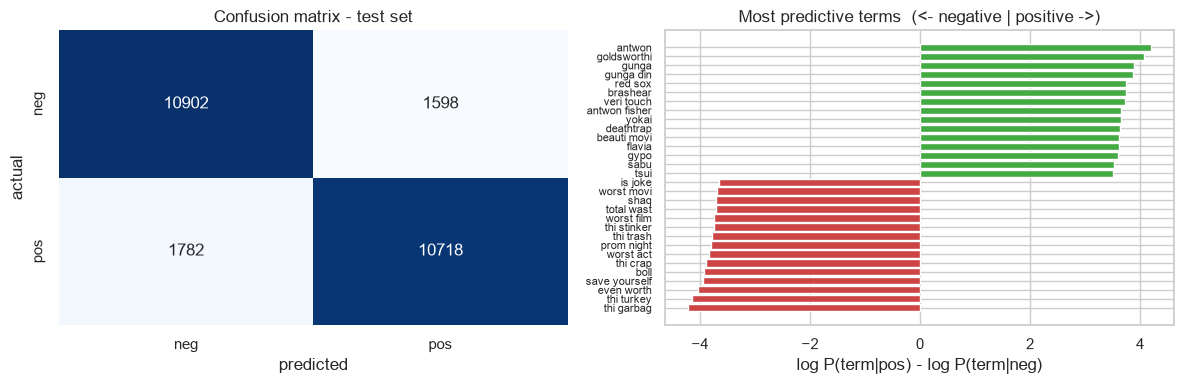

In [25]:
cm = confusion_matrix(yte, test_pred)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["neg", "pos"], yticklabels=["neg", "pos"], ax=ax[0])
ax[0].set_xlabel("predicted"); ax[0].set_ylabel("actual"); ax[0].set_title("Confusion matrix - test set")

# most predictive terms per class, by log-likelihood ratio
llr = final_clf.feature_log_prob_[1] - final_clf.feature_log_prob_[0]
vocab = np.array(final_vec.get_feature_names_out())
k = 15
idx = np.concatenate([np.argsort(llr)[:k], np.argsort(llr)[-k:]])
colors = ["#cc4444"] * k + ["#44aa44"] * k
ax[1].barh(range(2 * k), llr[idx], color=colors)
ax[1].set_yticks(range(2 * k)); ax[1].set_yticklabels(vocab[idx], fontsize=8)
ax[1].set_title("Most predictive terms  (<- negative | positive ->)")
ax[1].set_xlabel("log P(term|pos) - log P(term|neg)")
plt.tight_layout(); plt.show()

---
## Conclusions

- The full supervised flow ran end to end on the fixed IMDB train/test split: text cleaning ->
  tokenisation -> BoW / TF-IDF vectorisation -> a **from-scratch Naive Bayes** classifier, selected
  by leakage-safe 5-fold cross-validated grid search and evaluated once on the test set.
- The from-scratch `NaiveBayesTextClassifier` reproduces scikit-learn's `MultinomialNB` /
  `BernoulliNB` to ~1e-13, so the algorithm is implemented correctly.
- The final test score lands a little over one point below the cross-validated estimate from
  Part 6a (and further below the resubstitution score on the training set in Part 4). A small drop
  in that direction is exactly what an honest evaluation looks like: cross-validation is mildly
  optimistic because each configuration was *chosen* by its cross-validated score, and the Stanford
  split deliberately keeps the films in the test set disjoint from those in the training set - so
  the movie-specific vocabulary the model picks up (actor and character names, as visible in the
  traced examples) does not transfer. There is no sign of leakage or of tuning against the test set,
  which would have shown up as the opposite pattern.
- Most-predictive-term analysis shows the model keys on exactly the words a human would use to
  judge sentiment.
- What we would try next, given more time: keeping negation ("not good" as a feature is already
  captured by bigrams, but explicit negation-scoping would go further), lemmatisation instead of
  Porter stemming, and lifting the 30,000-feature cap now that we know `max_features` - not
  `min_df` - is the binding pruning constraint.
- Not pursued here (possible extensions from the brief): imbalanced-data techniques (6b - not
  needed, this dataset is 50/50), and model-agnostic explainability such as SHAP (6c).

### Appendix - values for the shared Excel sheet

| Field | Value |
|---|---|
| Assignment type | text analysis (NLP) |
| Learning type | classification (binary) |
| Learning algorithm implemented | Naive Bayes (Multinomial + Bernoulli), from scratch |
| Dataset name | IMDB 50K Movie Reviews (TEST your BERT) |
| Dataset URL | https://www.kaggle.com/datasets/atulanandjha/imdb-50k-movie-reviews-test-your-bert |
| Repository URL | https://github.com/Tomer-Raz/machine-learning-hit |
| Video URL | *(to be added)* |